# MLS-SRTP Figures

This notebook generates figures from the Criterion benchmark results.

## Prerequisites: 

Run the benchmarks and copy results:
```bash
./run_end_to_end.sh
```

Or run individual benchmarks manually:
```bash
cargo bench --package mls-srtp-core --bench srtp_throughput_criterion
cargo bench --package mls-srtp-core --bench rekey
cargo bench --package mls-srtp-core --bench key_derivation
```

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Global matplotlib style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# All Criterion results are copied here by run_end_to_end.sh
CRITERION_DIR = Path('crates/mls-srtp-core/benches/results/criterion')

# SRTP throughput (encrypt/decrypt across 15 payload sizes)
RESULTS_DIR = CRITERION_DIR / 'srtp_throughput' / 'protect'
UNPROTECT_RESULTS_DIR = CRITERION_DIR / 'srtp_throughput' / 'unprotect'

# PEP throughput (CTR and CTR_CMAC-64 modes, encrypt/decrypt)
PEP_DIR = CRITERION_DIR / 'pep_throughput'

# MLS rekey (sender/receiver pipeline across group sizes)
REKEY_DIR = CRITERION_DIR / 'rekey'

# MLS rekey breakdown (component-level measurements)
REKEY_BREAKDOWN_DIR = CRITERION_DIR / 'rekey_breakdown'

# Key derivation (MLS export + SRTP KDF)
KEY_DERIVATION_DIR = CRITERION_DIR / 'key_derivation'

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
def load_criterion_results(results_dir: Path) -> dict:
    """Loads Criterion benchmark results from a directory of payload-size subdirs.
    
    Works for both SRTP and PEP benchmarks, i.e. any Criterion group where each
    subdirectory contains benchmark.json (with a throughput field and a label
    like "1424B_standard") and estimates.json (with mean/std_dev).
    
    Returns a dict mapping payload_size (int) -> {
        'label': str, 'payload_bytes': int, 'packet_bytes': int,
        'mean_ns': float, 'std_ns': float, 'throughput_gbps': float
    }
    """
    results = {}
    
    for entry in sorted(results_dir.iterdir()):
        
        # skipping the top-level "report/" folder (Criterion's summary HTML)
        if not entry.is_dir() or entry.name == 'report':
            continue
        
        # each benchmark run has benchmark.json (metadata) and estimates.json (stats)
        bench_path = entry / 'new' / 'benchmark.json'
        est_path = entry / 'new' / 'estimates.json'
        
        if not bench_path.exists() or not est_path.exists():
            continue
        
        with open(bench_path) as f:
            bench = json.load(f)
        with open(est_path) as f:
            estimates = json.load(f)
        
        label = bench['value_str']
        
        # criterion's "Bytes" throughput field = total packet size on the wire
        # (for SRTP: 12 B RTP header + payload + 16 B GCM tag)
        # (for PEP CTR: 12 B RTP header + payload)
        # (for PEP CTR+CMAC: 12 B RTP header + payload + 8 B CMAC tag)
        packet_bytes = bench['throughput']['Bytes']
        
        mean_ns = estimates['mean']['point_estimate']
        std_ns = estimates['std_dev']['point_estimate']
        
        # extracting the numeric payload size from the label 
        # (e.g. "1424B_standard" -> 1424)
        match = re.match(r'(\d+)B', label)
        if match:
            payload_size = int(match.group(1))
        else:
            continue
        
        # bits/ns = Gbps (since 1 bit/ns = 1 Gbps)
        throughput_gbps = (packet_bytes * 8) / mean_ns
        
        results[payload_size] = {
            'label': label,
            'payload_bytes': payload_size,
            'packet_bytes': packet_bytes,
            'mean_ns': mean_ns,
            'std_ns': std_ns,
            'throughput_gbps': throughput_gbps,
        }
    
    # sorting by payload size
    return dict(sorted(results.items()))


results = load_criterion_results(RESULTS_DIR)

print(f'Loaded {len(results)} benchmark results:')
print(f'{"Payload":>8s}  {"Mean (ns)":>10s}  {"Throughput":>12s}')
print('-' * 34)
for sz, r in results.items():
    print(f'{sz:>7d}B  {r["mean_ns"]:>10.1f}  {r["throughput_gbps"]:>10.2f} Gbps')

Loaded 15 benchmark results:
 Payload   Mean (ns)    Throughput
----------------------------------
     16B       102.4        3.44 Gbps
     32B       106.1        4.52 Gbps
     40B       112.4        4.84 Gbps
     64B       109.6        6.71 Gbps
    128B       118.7       10.51 Gbps
    160B       127.4       11.80 Gbps
    256B       145.4       15.62 Gbps
    512B       158.5       27.25 Gbps
    800B       186.0       35.60 Gbps
   1024B       211.5       39.80 Gbps
   1200B       230.3       42.66 Gbps
   1424B       252.2       46.06 Gbps
   2048B       317.8       52.26 Gbps
   4096B       530.3       62.21 Gbps
   8924B      1038.4       68.97 Gbps


In [3]:
# Loading decryption (unprotect) results using the same loader function
unprotect_results = load_criterion_results(UNPROTECT_RESULTS_DIR)

print(f'Loaded {len(unprotect_results)} unprotect benchmark results:')
print(f'{"Payload":>8s}  {"Mean (ns)":>10s}  {"Throughput":>12s}')
print('-' * 34)
for sz, r in unprotect_results.items():
    print(f'{sz:>7d}B  {r["mean_ns"]:>10.1f}  {r["throughput_gbps"]:>10.2f} Gbps')

Loaded 15 unprotect benchmark results:
 Payload   Mean (ns)    Throughput
----------------------------------
     16B       126.9        2.77 Gbps
     32B       126.8        3.79 Gbps
     40B       132.1        4.12 Gbps
     64B       127.6        5.77 Gbps
    128B       137.0        9.11 Gbps
    160B       144.5       10.41 Gbps
    256B       161.6       14.06 Gbps
    512B       197.1       21.92 Gbps
    800B       227.0       29.18 Gbps
   1024B       242.6       34.69 Gbps
   1200B       267.5       36.72 Gbps
   1424B       294.3       39.47 Gbps
   2048B       352.8       47.07 Gbps
   4096B       574.7       57.40 Gbps
   8924B      1179.6       60.71 Gbps


## Figure 1: SRTP Throughput vs. Uncompressed Video Bitrates

Throughput (Gbps) for SRTP `protect()` (encrypt) and `unprotect()` (decrypt)
across 15 payload sizes. Both operations are pure crypto (no network or
packet construction overhead). Reference lines show uncompressed video
bitrates (ST 2110, 4:2:2, 10-bit).

Data from Criterion results in `criterion/srtp_throughput/`.

In [4]:
# --- Uncompressed video bitrates (ST 2110, 4:2:2, 10-bit) ---
# These are reference bitrates from the table provided by the EBU. 
# They are used as horizontal reference lines in the throughput plot 
# to show how SRTP compares to real workloads.

video_formats = [
    # (label,       bitrate_gbps, resolution_group)
    ('720p50',       0.96,  '720p'),
    ('720p60',       1.15,  '720p'),
    ('1080p50',      2.15,  '1080p'),
    ('1080p60',      2.58,  '1080p'),
    ('2160p50',      8.60,  '2160p'),
    ('2160p60',     10.32,  '2160p'),
    ('2160p120',    20.65,  '2160p'),
    ('2160p300',    51.62,  '2160p'),
    ('4320p50',     34.41,  '4320p'),
    ('4320p60',     41.29,  '4320p'),
]

# Color scheme by resolution family
resolution_colors = {
    '720p':  '#27ae60',
    '1080p': '#2980b9',
    '2160p': '#e67e22',
    '4320p': '#8e44ad',
}

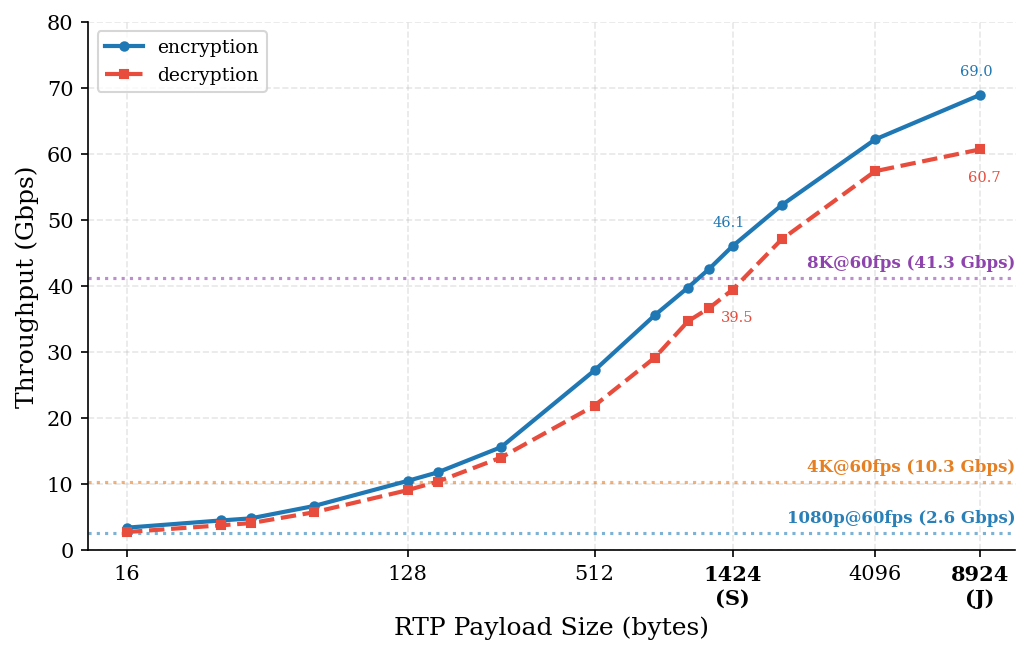

In [5]:
# Extracting sorted payload sizes and corresponding throughputs 
# from benchmark results
payload_sizes = np.array(list(results.keys()))
throughput_gbps = np.array([r['throughput_gbps'] for r in results.values()])

# decrypt throughput (same payload sizes since both benchmarks use same set)
unprotect_payload_sizes = np.array(list(unprotect_results.keys()))
unprotect_throughput_gbps = np.array([r['throughput_gbps'] for r in unprotect_results.values()])

fig, ax = plt.subplots(figsize=(7, 4.5))

# --- SRTP throughput curves ---
ax.plot(payload_sizes, throughput_gbps, 'o-', color='#1f77b4', linewidth=2,
        markersize=4, zorder=5, label='encryption')
ax.plot(unprotect_payload_sizes, unprotect_throughput_gbps, 's--', color='#e74c3c',
        linewidth=2, markersize=4, zorder=5, label='decryption')

# --- Value labels at the two MTU sizes ---
# encrypt above, decrypt below, consistent 8pt offset, colors match lines
pt_off = 10
for sz in [1424, 8924]:
    tp_enc = results[sz]['throughput_gbps']
    ax.annotate(f'{tp_enc:.1f}', (sz, tp_enc),
                textcoords='offset points', xytext=(-2, pt_off - 2),
                fontsize=7, ha='center', va='bottom', color='#1f77b4')
    tp_dec = unprotect_results[sz]['throughput_gbps']
    ax.annotate(f'{tp_dec:.1f}', (sz, tp_dec),
                textcoords='offset points', xytext=(+2, -pt_off),
                fontsize=7, ha='center', va='top', color='#e74c3c')

# --- Video bitrate reference lines ---
y_max = 80

display_formats = {
    '1080p60': '1080p',
    '2160p60': '4K',
    '4320p60': '8K',
}

for label, bitrate, res_group in video_formats:
    if label not in display_formats:
        continue
    display_label = display_formats[label]
    color = resolution_colors[res_group]
    ax.axhline(y=bitrate, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    ax.text(1.0, bitrate + 1.0, f'{display_label}@60fps ({bitrate:.1f} Gbps)',
            va='bottom', ha='right', fontsize=8, color=color, fontweight='bold',
            transform=ax.get_yaxis_transform())

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Throughput (Gbps)')

# (S) and (J) on a new line under 1424 and 8924
xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

ax.set_ylim(0, y_max)
ax.set_xlim(12, payload_sizes[-1] * 1.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig1_srtp_throughput.pdf')
plt.savefig(FIGURES_DIR / 'fig1_srtp_throughput.png')
plt.show()

## Figure 2: SRTP Per-Packet Latency vs. Payload Size

Per-packet latency (ns) for SRTP `protect()` and `unprotect()` across all
15 payload sizes. This is the same benchmark data as Figure 1, showing latency instead of throughput.

Data from Criterion results in `criterion/srtp_throughput/`.

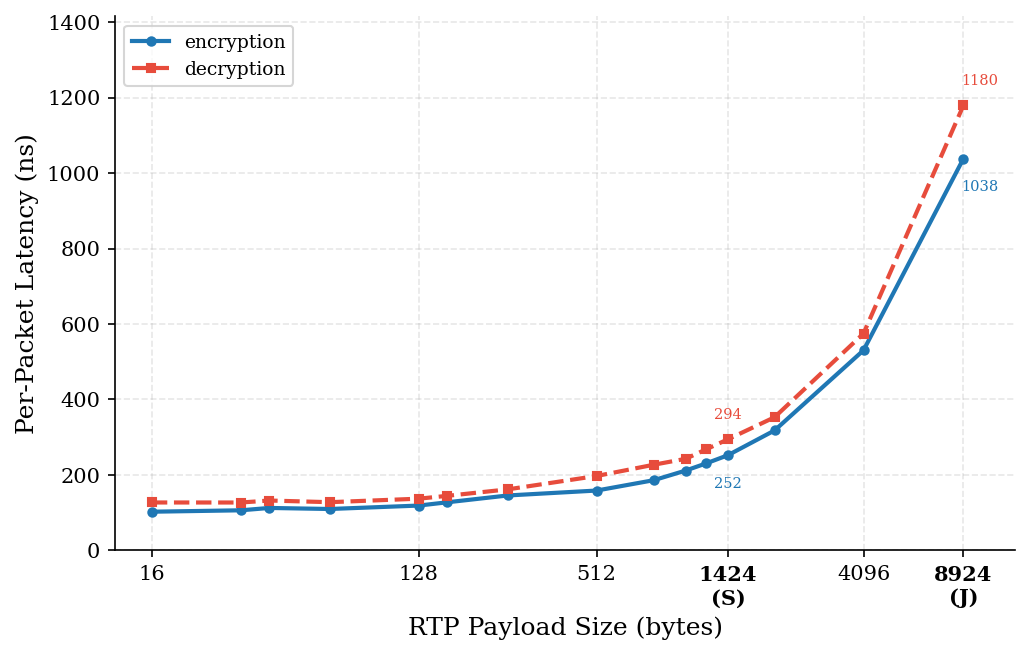

In [6]:
# --- Figure 2: SRTP per-packet latency ---
# Same benchmark data as Figure 1, showing latency instead of throughput.

common_sizes = sorted(set(results.keys()) & set(unprotect_results.keys()))
lat_sizes = np.array(common_sizes)
protect_ns = np.array([results[sz]['mean_ns'] for sz in common_sizes])
unprotect_ns = np.array([unprotect_results[sz]['mean_ns'] for sz in common_sizes])

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(lat_sizes, protect_ns, 'o-', color='#1f77b4', linewidth=2,
        markersize=4, zorder=5, label='encryption')
ax.plot(lat_sizes, unprotect_ns, 's--', color='#e74c3c', linewidth=2,
        markersize=4, zorder=5, label='decryption')

# --- Value labels at the two MTU sizes ---
pt_off = 10
for sz in [1424, 8924]:
    jumbo = sz == 8924;    
    ns_enc = results[sz]['mean_ns']
    ax.annotate(f'{ns_enc:.0f}', (sz, ns_enc),
                textcoords='offset points', xytext=(jumbo * 8, -pt_off - 7),
                fontsize=7, ha='center', va='bottom', color='#1f77b4')
    ns_dec = unprotect_results[sz]['mean_ns']
    ax.annotate(f'{ns_dec:.0f}', (sz, ns_dec),
                textcoords='offset points', xytext=(jumbo * 8, pt_off + 5),
                fontsize=7, ha='center', va='top', color='#e74c3c')

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Per-Packet Latency (ns)')

xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

ax.set_ylim(0, max(unprotect_ns) * 1.2)
ax.set_xlim(12, lat_sizes[-1] * 1.5)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_srtp_latency.pdf')
plt.savefig(FIGURES_DIR / 'fig2_srtp_latency.png')
plt.show()

## Table 1: SRTP Performance Summary

Key numbers for the two ST 2110-10 MTU sizes.

Data from Criterion results in `criterion/srtp_throughput/` and
`benches/results/mls_srtp_operations/results.md` (replay protection).

In [7]:
# --- Table 1: SRTP performance summary ---

# replay protection is constant at ~3.6 ns regardless of payload size
# (from benches/results/mls_srtp_operations/results.md)
replay_ns = 3.55

mtu_sizes = [1424, 8924]

# collecting protect/unprotect data for both MTU sizes
row_data = []
for sz in mtu_sizes:
    row_data.append((results[sz], unprotect_results[sz]))

def fmt_ns(ns):
    """Formats nanoseconds, switching to \u00b5s if >= 1000."""
    if ns >= 1000:
        return f'{ns/1000:.2f} \u00b5s'
    return f'{ns:.1f} ns'

metrics = [
    ('Encrypt latency',    [fmt_ns(row_data[i][0]['mean_ns']) for i in range(2)]),
    ('Decrypt latency',    [fmt_ns(row_data[i][1]['mean_ns']) for i in range(2)]),
    ('Replay  check',       [fmt_ns(replay_ns)] * 2),
    ('Encrypt throughput', [f'{row_data[i][0]["throughput_gbps"]:.1f} Gbps' for i in range(2)]),
    ('Decrypt throughput', [f'{row_data[i][1]["throughput_gbps"]:.1f} Gbps' for i in range(2)]),
]

print(f'{"Metric":<24s}  {"Standard MTU":>14s}  {"Jumbo MTU":>14s}')
print('-' * 56)
for name, vals in metrics:
    print(f'{name:<24s}  {vals[0]:>14s}  {vals[1]:>14s}')

Metric                      Standard MTU       Jumbo MTU
--------------------------------------------------------
Encrypt latency                 252.2 ns         1.04 µs
Decrypt latency                 294.3 ns         1.18 µs
Replay  check                     3.5 ns          3.5 ns
Encrypt throughput             46.1 Gbps       69.0 Gbps
Decrypt throughput             39.5 Gbps       60.7 Gbps


## Table 2: SRTP Packet Size Overhead

SRTP with AES-128-GCM adds a constant 16-byte authentication tag per packet
(RFC 7714). The 12-byte RTP header is authenticated but not encrypted.
The overhead is most significant for small audio packets and negligible
for large video payloads.

In [8]:
# --- Table 2: Packet size overhead ---


# RTP header is always 12 bytes (RFC 3550, no CSRCs or extensions).
RTP_HDR = 12   # bytes

# SRTP adds a fixed 16-byte GCM authentication tag to every packet.
GCM_TAG = 16   # bytes

# representative payload sizes with their use-case labels
overhead_sizes = [
    (40,   'Wideband speech'),
    (160,  'Fullband mono music'),
    (800,  'Video fragment (small)'),
    (1200, 'Video fragment (near-MTU)'),
    (1424, 'ST 2110 standard MTU'),
    (8924, 'ST 2110 jumbo MTU'),
]

print(f'{"Payload":<8s}  {"Use Case":<26s}  {"RTP":>6s}  {"SRTP":>6s}  {"Overhead":>9s}')
print('-' * 60)
for payload, use_case in overhead_sizes:
    rtp_size = RTP_HDR + payload
    srtp_size = rtp_size + GCM_TAG
    overhead_pct = GCM_TAG / rtp_size * 100
    print(f'{payload:>6d} B  {use_case:<26s}  {rtp_size:>5d} B  {srtp_size:>5d} B  {overhead_pct:>7.1f} %')

Payload   Use Case                       RTP    SRTP   Overhead
------------------------------------------------------------
    40 B  Wideband speech                52 B     68 B     30.8 %
   160 B  Fullband mono music           172 B    188 B      9.3 %
   800 B  Video fragment (small)        812 B    828 B      2.0 %
  1200 B  Video fragment (near-MTU)    1212 B   1228 B      1.3 %
  1424 B  ST 2110 standard MTU         1436 B   1452 B      1.1 %
  8924 B  ST 2110 jumbo MTU            8936 B   8952 B      0.2 %


## Figure 3: SRTP vs. PEP Throughput

Throughput (Gbps) comparison between SRTP (AES-128-GCM via libsrtp2) and
PEP (VSF TR-10-13) in two modes:
- **PEP CTR**: AES-128-CTR only (mandatory mode, no authentication)
- **PEP CTR+CMAC-64**: AES-128-CTR + 64-bit truncated AES-CMAC
  (mac-then-encrypt, optional authenticated mode)

Data from Criterion results in `criterion/srtp_throughput/` and
`criterion/pep_throughput/`.

Figure 3 = encryption, Figure 4 = decryption.

In [9]:
# --- Loading PEP benchmark results ---

pep_ctr_enc     = load_criterion_results(PEP_DIR / 'ctr_encrypt')
pep_ctr_dec     = load_criterion_results(PEP_DIR / 'ctr_decrypt')
pep_cmac_enc    = load_criterion_results(PEP_DIR / 'ctr_cmac64_encrypt')
pep_cmac_dec    = load_criterion_results(PEP_DIR / 'ctr_cmac64_decrypt')

print(f'Loaded PEP results: {len(pep_ctr_enc)} payload sizes per mode')
print()
print(f'{"Payload":>8s}  {"CTR enc":>10s}  {"CTR dec":>10s}  {"CMAC enc":>10s}  {"CMAC dec":>10s}')
print('-' * 54)
for sz in sorted(pep_ctr_enc.keys()):
    print(f'{sz:>7d}B  {pep_ctr_enc[sz]["mean_ns"]:>9.1f}  {pep_ctr_dec[sz]["mean_ns"]:>9.1f}'
          f'  {pep_cmac_enc[sz]["mean_ns"]:>9.1f}  {pep_cmac_dec[sz]["mean_ns"]:>9.1f}')

Loaded PEP results: 15 payload sizes per mode

 Payload     CTR enc     CTR dec    CMAC enc    CMAC dec
------------------------------------------------------
     16B       58.6       57.6     1584.8     1609.4
     32B       59.5       58.2     1615.8     1614.4
     40B       47.7       48.4     1618.7     1618.4
     64B       45.9       46.4     1617.1     1620.4
    128B       49.5       50.1     1655.0     1655.5
    160B       53.0       53.9     1663.6     1760.2
    256B       60.4       60.8     1734.0     1740.3
    512B       81.8       79.5     1960.8     1902.3
    800B       97.9       99.0     2122.1     2084.0
   1024B      115.7      116.9     2227.0     2288.7
   1200B      127.0      127.2     2338.4     2354.4
   1424B      148.4      145.2     2549.2     2482.8
   2048B      188.9      189.7     2869.4     2874.8
   4096B      343.3      349.4     4199.7     4271.5
   8924B      695.5      700.0     7310.8     7325.3


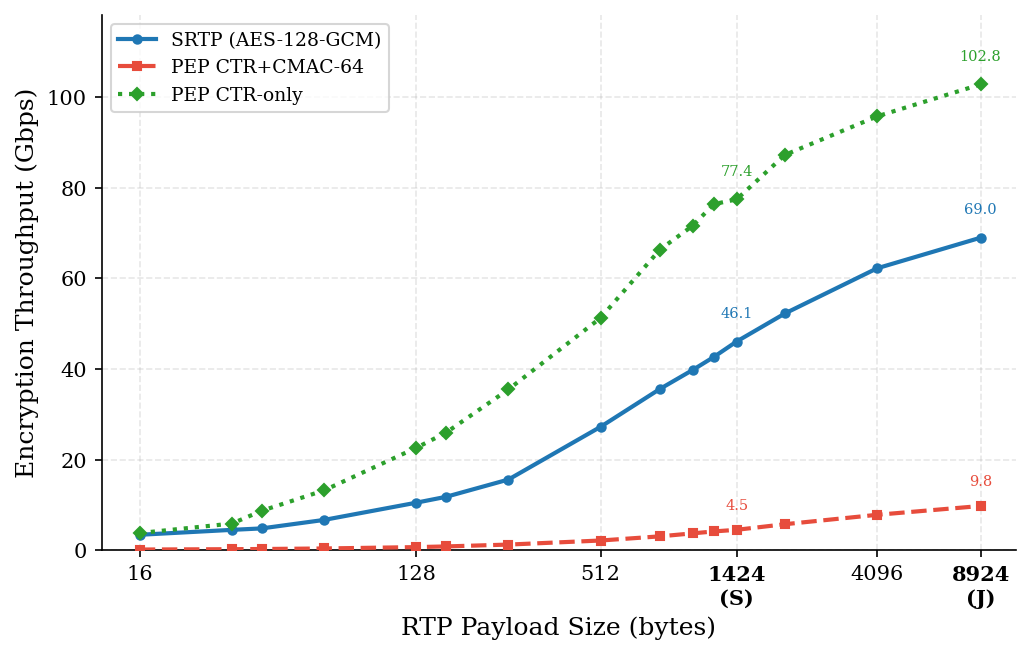

In [10]:
# --- Figure 3: SRTP vs PEP encryption throughput ---

common = sorted(set(results.keys()) & set(pep_ctr_enc.keys()))
sizes = np.array(common)

srtp_enc_tp     = np.array([results[sz]['throughput_gbps'] for sz in common])
pep_ctr_enc_tp  = np.array([pep_ctr_enc[sz]['throughput_gbps'] for sz in common])
pep_cmac_enc_tp = np.array([pep_cmac_enc[sz]['throughput_gbps'] for sz in common])

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(sizes, srtp_enc_tp, 'o-', color='#1f77b4', linewidth=2,
        markersize=4, zorder=5, label='SRTP (AES-128-GCM)')
ax.plot(sizes, pep_cmac_enc_tp, 's--', color='#e74c3c', linewidth=2,
        markersize=4, zorder=5, label='PEP CTR+CMAC-64')
ax.plot(sizes, pep_ctr_enc_tp, 'D:', color='#2ca02c', linewidth=2,
        markersize=4, zorder=5, label='PEP CTR-only')

# --- Value labels at the two MTU sizes ---
pt_off = 10
for sz in [1424, 8924]:
    tp = results[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off),
                fontsize=7, ha='center', va='bottom', color='#1f77b4')
    tp = pep_cmac_enc[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off + 5),
                fontsize=7, ha='center', va='top', color='#e74c3c')
    tp = pep_ctr_enc[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off),
                fontsize=7, ha='center', va='bottom', color='#2ca02c')

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Encryption Throughput (Gbps)')

xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

y_max = max(max(srtp_enc_tp), max(pep_ctr_enc_tp), max(pep_cmac_enc_tp)) * 1.15
ax.set_ylim(0, y_max)
ax.set_xlim(12, sizes[-1] * 1.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig3_srtp_vs_pep_encrypt.pdf')
plt.savefig(FIGURES_DIR / 'fig3_srtp_vs_pep_encrypt.png')
plt.show()

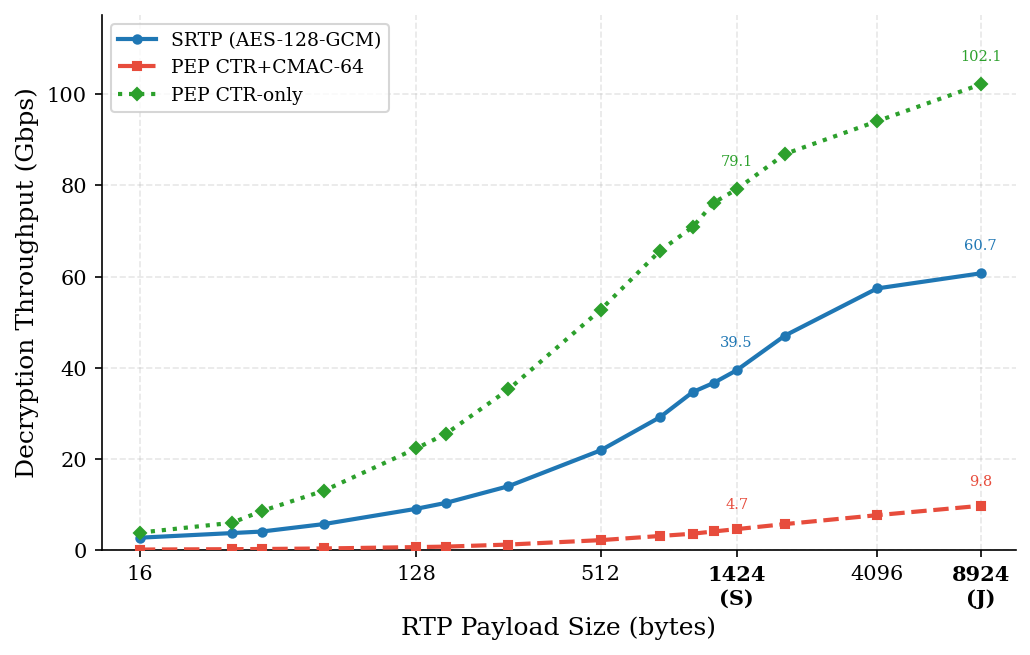

In [11]:
# --- Figure 4: SRTP vs PEP decryption throughput ---

srtp_dec_tp     = np.array([unprotect_results[sz]['throughput_gbps'] for sz in common])
pep_ctr_dec_tp  = np.array([pep_ctr_dec[sz]['throughput_gbps'] for sz in common])
pep_cmac_dec_tp = np.array([pep_cmac_dec[sz]['throughput_gbps'] for sz in common])

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(sizes, srtp_dec_tp, 'o-', color='#1f77b4', linewidth=2,
        markersize=4, zorder=5, label='SRTP (AES-128-GCM)')
ax.plot(sizes, pep_cmac_dec_tp, 's--', color='#e74c3c', linewidth=2,
        markersize=4, zorder=5, label='PEP CTR+CMAC-64')
ax.plot(sizes, pep_ctr_dec_tp, 'D:', color='#2ca02c', linewidth=2,
        markersize=4, zorder=5, label='PEP CTR-only')

# --- Value labels at the two MTU sizes ---
pt_off = 10
for sz in [1424, 8924]:
    tp = unprotect_results[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off),
                fontsize=7, ha='center', va='bottom', color='#1f77b4')
    tp = pep_cmac_dec[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off + 5),
                fontsize=7, ha='center', va='top', color='#e74c3c')
    tp = pep_ctr_dec[sz]['throughput_gbps']
    ax.annotate(f'{tp:.1f}', (sz, tp),
                textcoords='offset points', xytext=(0, pt_off),
                fontsize=7, ha='center', va='bottom', color='#2ca02c')

# --- Axis formatting ---
ax.set_xscale('log', base=2)
ax.set_xlabel('RTP Payload Size (bytes)')
ax.set_ylabel('Decryption Throughput (Gbps)')

xtick_sizes = [16, 128, 512, 1424, 4096, 8924]
xtick_labels = ['16', '128', '512', '1424\n(S)', '4096', '8924\n(J)']
ax.set_xticks(xtick_sizes)
ax.set_xticklabels(xtick_labels, rotation=0, ha='center')
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

for lbl in ax.xaxis.get_ticklabels():
    if '(S)' in lbl.get_text() or '(J)' in lbl.get_text():
        lbl.set_fontweight('bold')

y_max = max(max(srtp_dec_tp), max(pep_ctr_dec_tp), max(pep_cmac_dec_tp)) * 1.15
ax.set_ylim(0, y_max)
ax.set_xlim(12, sizes[-1] * 1.3)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig4_srtp_vs_pep_decrypt.pdf')
plt.savefig(FIGURES_DIR / 'fig4_srtp_vs_pep_decrypt.png')
plt.show()

## Figure 5: MLS Rekey Latency vs. Group Size

Time to perform a group rekey (epoch change) for different MLS group sizes.
A rekey is a self-update commit that advances the group to a new epoch with
fresh key material and triggers SRTP key rotation.

Data from Criterion results in `criterion/rekey/`.

Loaded rekey results for 7 group sizes:
 Members   Sender (µs)   Receiver (µs)
--------------------------------------
       2           271             267
      10           555             441
      50          1056             810
     200          2686            2106
     500          5469            4312
    1000         10242            8177
    5000         56680           47353


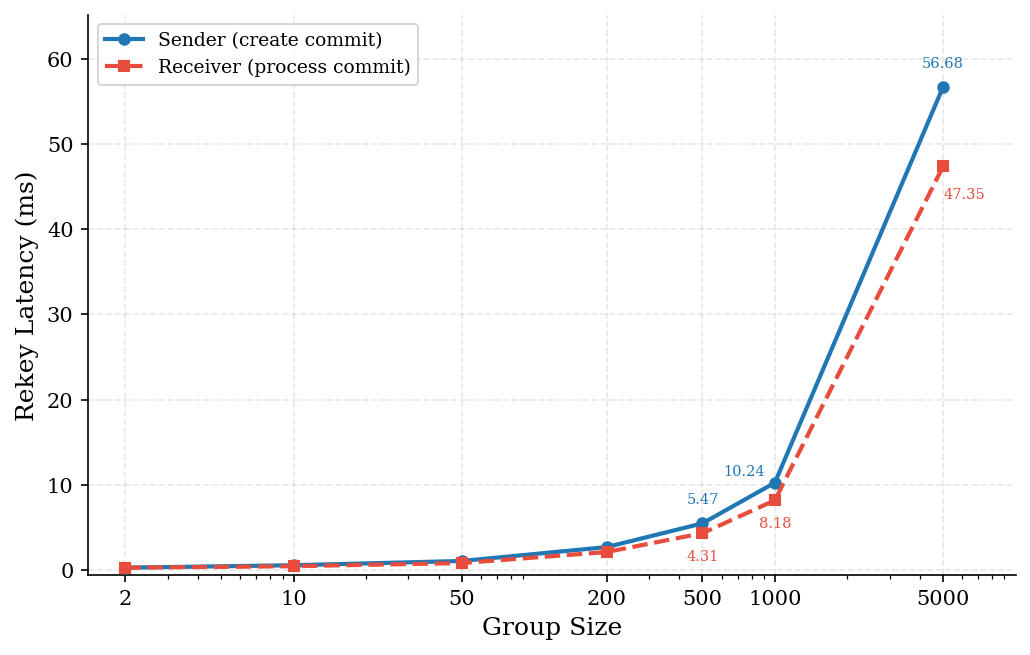

In [12]:
# --- MLS rekey latency data (from Criterion JSON) ---
# "Sender" = creating the rekey commit + exporting SRTP keys
# "Receiver" = processing the incoming commit + exporting SRTP keys.

def load_rekey_results(rekey_dir: Path) -> dict:
    """Loads sender and receiver rekey pipeline latencies from Criterion JSON.
    
    Returns dict with 'group_sizes', 'sender_us', 'receiver_us' arrays.
    """
    group_sizes = []
    sender_us = []
    receiver_us = []
    
    sender_dir = rekey_dir / 'sender_rekey_pipeline'
    receiver_dir = rekey_dir / 'receiver_rekey_pipeline'
    
    # each subdirectory is named by group size (e.g. "2", "10", "50", ...)
    for entry in sorted(sender_dir.iterdir(), key=lambda p: int(p.name) if p.name.isdigit() else 0):
        if not entry.is_dir() or not entry.name.isdigit():
            continue
        
        n = int(entry.name)
        
        # sender
        est_path = entry / 'new' / 'estimates.json'
        with open(est_path) as f:
            sender_ns = json.load(f)['mean']['point_estimate']
        
        # receiver
        recv_est = receiver_dir / entry.name / 'new' / 'estimates.json'
        with open(recv_est) as f:
            receiver_ns = json.load(f)['mean']['point_estimate']
        
        group_sizes.append(n)
        sender_us.append(sender_ns / 1000)   # ns -> µs
        receiver_us.append(receiver_ns / 1000)
    
    return {
        'group_sizes': np.array(group_sizes),
        'sender_us': np.array(sender_us),
        'receiver_us': np.array(receiver_us),
    }

rekey = load_rekey_results(REKEY_DIR)
group_sizes = rekey['group_sizes']
sender_rekey_us = rekey['sender_us']
receiver_rekey_us = rekey['receiver_us']

print(f'Loaded rekey results for {len(group_sizes)} group sizes:')
print(f'{"Members":>8s}  {"Sender (µs)":>12s}  {"Receiver (µs)":>14s}')
print('-' * 38)
for i in range(len(group_sizes)):
    print(f'{group_sizes[i]:>8d}  {sender_rekey_us[i]:>12.0f}  {receiver_rekey_us[i]:>14.0f}')

# converting to milliseconds for a cleaner y-axis
sender_rekey_ms = sender_rekey_us / 1000.0
receiver_rekey_ms = receiver_rekey_us / 1000.0

fig, ax = plt.subplots(figsize=(7, 4.5))

# --- Rekey latency curves ---
ax.plot(group_sizes, sender_rekey_ms, 'o-', color='#1f77b4', linewidth=2,
        markersize=5, zorder=5, label='Sender (create commit)')
ax.plot(group_sizes, receiver_rekey_ms, 's--', color='#e74c3c', linewidth=2,
        markersize=5, zorder=5, label='Receiver (process commit)')

# --- Annotating only the last 3 data points with values ---
pt_off = 8
n_pts = len(group_sizes)

# default offsets: sender above, receiver below
sender_xy   = [(0, pt_off, 'center')] * n_pts
receiver_xy = [(0, -pt_off, 'center')] * n_pts

# some tricks to make sure the value labels don't overlap at the last 2 points
if n_pts >= 5:
    sender_xy[-2]   = (-5, 2, 'right')
    receiver_xy[-1] = (0, -10, 'left')

for i, sz in enumerate(group_sizes):
    # only label the last 3 points
    if i < n_pts - 3:
        continue
    xo, yo, ha = sender_xy[i]
    ax.annotate(f'{sender_rekey_ms[i]:.2f}', (sz, sender_rekey_ms[i]),
                textcoords='offset points', xytext=(xo, yo),
                fontsize=7, ha=ha, va='bottom', color='#1f77b4')
    xo, yo, ha = receiver_xy[i]
    ax.annotate(f'{receiver_rekey_ms[i]:.2f}', (sz, receiver_rekey_ms[i]),
                textcoords='offset points', xytext=(xo, yo),
                fontsize=7, ha=ha, va='top', color='#e74c3c')

# --- Axis formatting ---
ax.set_xscale('log')
ax.set_xlabel('Group Size')
ax.set_ylabel('Rekey Latency (ms)')

ax.set_xticks(group_sizes)
ax.set_xticklabels([str(s) for s in group_sizes])
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_ylim(-0.6, max(sender_rekey_ms) * 1.15)
ax.set_xlim(group_sizes[0] * 0.7, group_sizes[-1] * 2)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig5_mls_rekey_latency.pdf')
plt.savefig(FIGURES_DIR / 'fig5_mls_rekey_latency.png')
plt.show()

## Figure 6: Rekey Cost Breakdown

Stacked bar chart showing the cost breakdown of the sender and receiver
rekey pipelines across group sizes. Each bar is decomposed into its
individual sub-operations:

**Sender pipeline:**
1. `propose_self_update` - generates leaf key pair + signs and encrypts Update proposal
2. `commit_builder.build()` - encrypts path secrets to copath nodes
3. `stage_commit()` - encrypts commit
4. `merge_pending_commit` - advances local state to new epoch

**Receiver pipeline:**
1. `unprotect_message` - decrypts commit
2. `process_unverified_message` - verifies signature + decrypts path secrets
3. `merge_staged_commit` - advances local state to new epoch

The SRTP key export (~4 µs) is omitted as it is negligible (<1% of total).
The `stage_commit` cost is derived by subtracting `build` from `build_and_stage`.

Data from Criterion results in `criterion/rekey_breakdown/`.

In [13]:
# --- Figure 6: Rekey cost breakdown (stacked bar chart) ---

def load_breakdown_results(breakdown_dir: Path) -> dict:
    """Loads component-level rekey latencies from Criterion JSON.
    
    Returns dict mapping component_name -> {group_size: mean_us, ...}.
    """
    components = {}
    
    for component_dir in sorted(breakdown_dir.iterdir()):
        if not component_dir.is_dir() or component_dir.name == 'report':
            continue
        
        name = component_dir.name
        components[name] = {}
        
        for size_dir in sorted(component_dir.iterdir(), 
                                key=lambda p: int(p.name) if p.name.isdigit() else 0):
            if not size_dir.is_dir() or not size_dir.name.isdigit():
                continue
            
            est_path = size_dir / 'new' / 'estimates.json'
            if not est_path.exists():
                continue
                
            with open(est_path) as f:
                mean_ns = json.load(f)['mean']['point_estimate']
            
            components[name][int(size_dir.name)] = mean_ns / 1000  # ns -> us
    
    return components

breakdown = load_breakdown_results(REKEY_BREAKDOWN_DIR)

# deriving stage_commit cost by subtraction (build_and_stage - build)
first_key = list(breakdown.keys())[0]
group_sizes_bd = sorted(breakdown[first_key].keys())

stage_commit_us = {}
for sz in group_sizes_bd:
    bas = breakdown['breakdown_sender_build_and_stage'].get(sz, 0)
    bo = breakdown['breakdown_sender_build'].get(sz, 0)
    stage_commit_us[sz] = max(0, bas - bo)

# printing summary table with figure labels
sender_rows = [
    ('Update proposal creation',  'breakdown_sender_propose'),
    ('Tree encryption',      'breakdown_sender_build'),
    ('Commit encryption',    '_stage_commit'),
    ('Epoch advancement',    'breakdown_sender_merge_pending'),
]
receiver_rows = [
    ('Commit decryption',    'breakdown_receiver_unprotect'),
    ('Path decryption',      'breakdown_receiver_verify_stage'),
    ('Epoch advancement',    'breakdown_receiver_merge_staged'),
]

def fmt_us(us):
    if us >= 1000:
        return f'{us/1000:.2f} ms'
    return f'{us:.1f} \u00b5s'

size_hdr = ''.join(f'{"n="+str(s):>12s}' for s in group_sizes_bd)
print(f'{"SENDER":<28s}{size_hdr}')
print('-' * (28 + 12 * len(group_sizes_bd)))
for label, key in sender_rows:
    vals = []
    for sz in group_sizes_bd:
        if key == '_stage_commit':
            vals.append(stage_commit_us.get(sz, 0))
        else:
            vals.append(breakdown[key].get(sz, 0))
    row = ''.join(f'{fmt_us(v):>12s}' for v in vals)
    print(f'{label:<28s}{row}')

print()
print(f'{"RECEIVER":<28s}{size_hdr}')
print('-' * (28 + 12 * len(group_sizes_bd)))
for label, key in receiver_rows:
    vals = [breakdown[key].get(sz, 0) for sz in group_sizes_bd]
    row = ''.join(f'{fmt_us(v):>12s}' for v in vals)
    print(f'{label:<28s}{row}')

SENDER                               n=2        n=10        n=50       n=200       n=500      n=1000      n=5000
----------------------------------------------------------------------------------------------------------------
Update proposal creation         94.9 µs    102.3 µs    112.0 µs    136.3 µs    175.4 µs    240.2 µs    824.4 µs
Tree encryption                 212.6 µs    459.4 µs    857.4 µs     2.09 ms     4.17 ms     7.80 ms    43.27 ms
Commit encryption                23.9 µs     33.7 µs     37.9 µs     56.7 µs     56.9 µs     80.8 µs    338.0 µs
Epoch advancement                19.1 µs     43.3 µs    147.9 µs    480.1 µs     1.13 ms     2.23 ms    12.27 ms

RECEIVER                             n=2        n=10        n=50       n=200       n=500      n=1000      n=5000
----------------------------------------------------------------------------------------------------------------
Commit decryption                18.7 µs     28.6 µs     40.8 µs     66.2 µs    105.7 µs    171

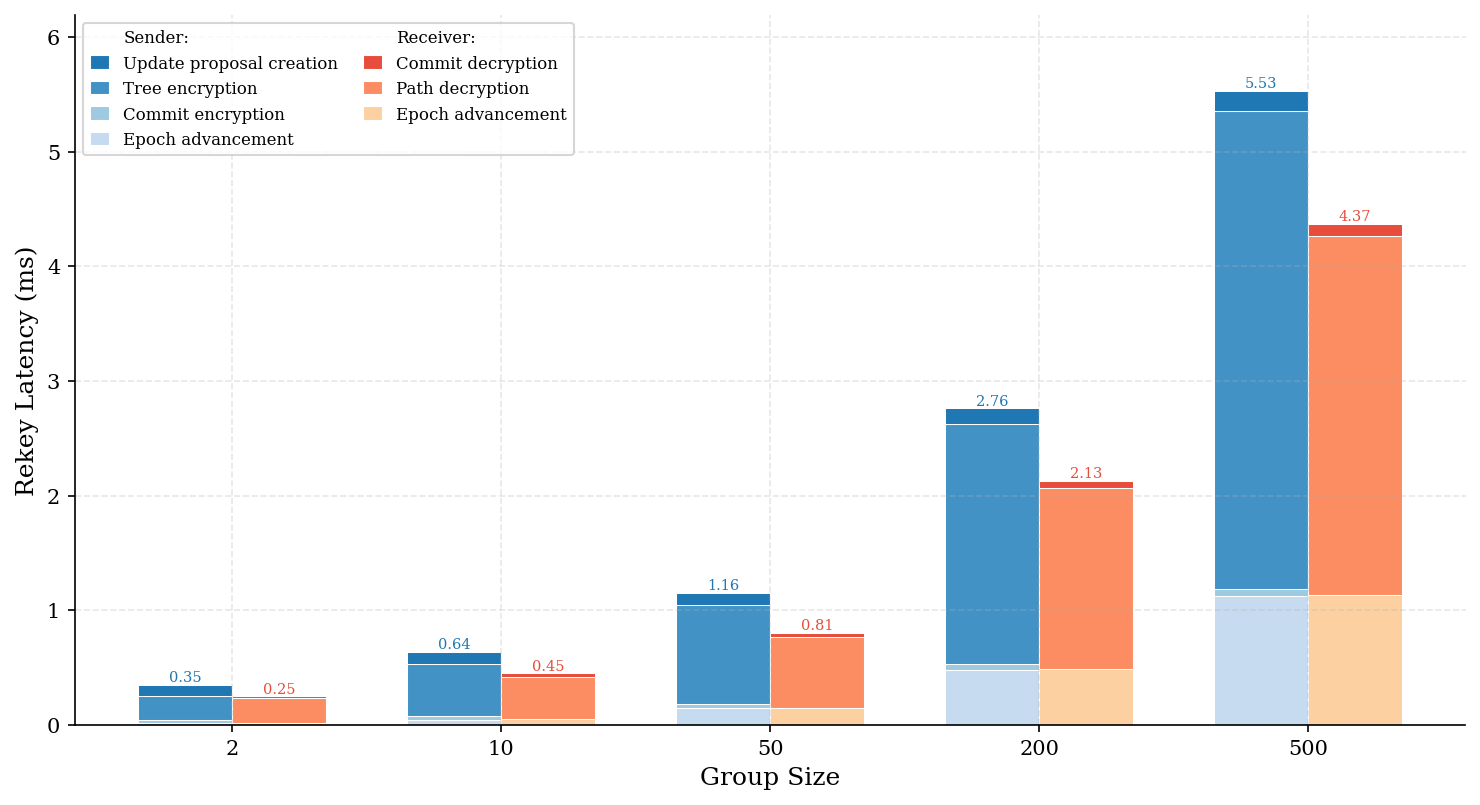

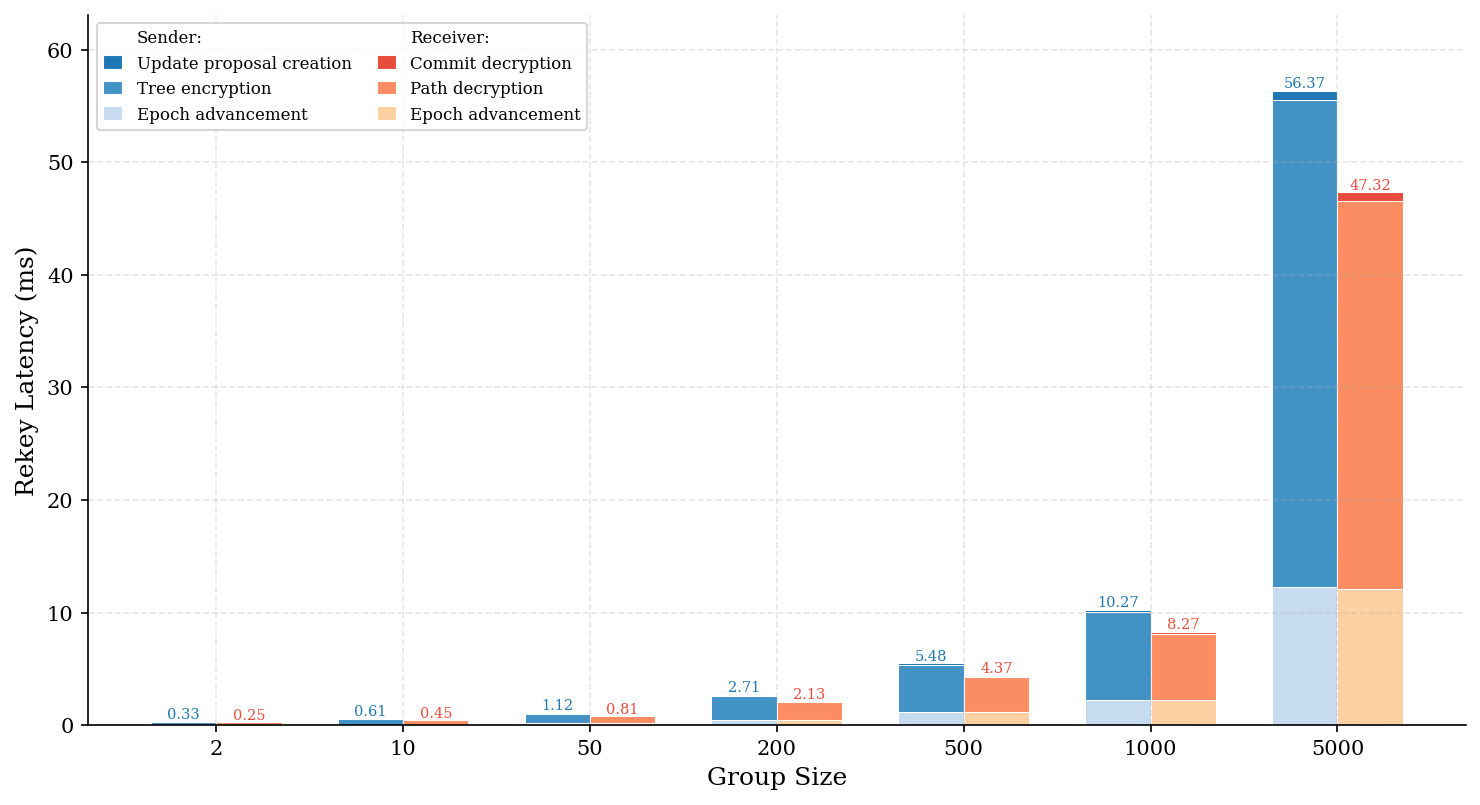

In [14]:
# --- Figure 6: Stacked bar chart (two versions: up to 500, up to 5000) ---

from matplotlib.patches import Patch

# getting group sizes from the first component
first_key = list(breakdown.keys())[0]
group_sizes_bd = sorted(breakdown[first_key].keys())

# deriving stage_commit cost
stage_commit_us = {}
for sz in group_sizes_bd:
    build_and_stage = breakdown['breakdown_sender_build_and_stage'].get(sz, 0)
    build_only = breakdown['breakdown_sender_build'].get(sz, 0)
    stage_commit_us[sz] = max(0, build_and_stage - build_only)

# component names in the order we want them stacked (bottom to top)
sender_components = [
    ('breakdown_sender_propose',        'Update proposal creation'),
    ('breakdown_sender_build',          'Tree encryption'),
    ('_stage_commit',                   'Commit encryption'),
    ('breakdown_sender_merge_pending',  'Epoch advancement'),
]
receiver_components = [
    ('breakdown_receiver_unprotect',     'Commit decryption'),
    ('breakdown_receiver_verify_stage',  'Path decryption'),
    ('breakdown_receiver_merge_staged',  'Epoch advancement'),
]

# colors: 4 shades for sender (blues), 3 shades for receiver (reds)
sender_colors   = ['#1f77b4', '#4292c6', '#9ecae1', '#c6dbef']
receiver_colors = ['#e74c3c', '#fc8d62', '#fdd0a2']


def plot_breakdown(sizes, suffix, figsize=(10, 5.5), include_commit_enc=True):
    """Plot a stacked bar chart for the given group sizes."""
    n_sizes = len(sizes)
    fig, ax = plt.subplots(figsize=figsize)

    bar_width = 0.35
    x = np.arange(n_sizes)

    # filter sender components if commit encryption is excluded
    if include_commit_enc:
        s_components = sender_components
        s_colors = sender_colors
    else:
        s_components = [(k, l) for k, l in sender_components if k != '_stage_commit']
        s_colors = [sender_colors[i] for i, (k, _) in enumerate(sender_components) if k != '_stage_commit']

    # --- sender bars (left) ---
    sender_bottom = np.zeros(n_sizes)
    for (key, label), color in zip(reversed(s_components), reversed(s_colors)):
        if key == '_stage_commit':
            values = np.array([stage_commit_us.get(sz, 0) for sz in sizes])
        else:
            values = np.array([breakdown[key].get(sz, 0) for sz in sizes])
        values_ms = values / 1000  # us -> ms
        ax.bar(x - bar_width/2, values_ms, bar_width, bottom=sender_bottom,
               color=color, edgecolor='white', linewidth=0.5)
        sender_bottom += values_ms

    # --- receiver bars (right) ---
    receiver_bottom = np.zeros(n_sizes)
    for (key, label), color in zip(reversed(receiver_components), reversed(receiver_colors)):
        values = np.array([breakdown[key].get(sz, 0) for sz in sizes])
        values_ms = values / 1000  # us -> ms
        ax.bar(x + bar_width/2, values_ms, bar_width, bottom=receiver_bottom,
               color=color, edgecolor='white', linewidth=0.5)
        receiver_bottom += values_ms

    # --- total value labels on top of each bar ---
    for i in range(n_sizes):
        ax.text(x[i] - bar_width/2, sender_bottom[i], f'{sender_bottom[i]:.2f}',
                ha='center', va='bottom', fontsize=7, color='#1f77b4')
        ax.text(x[i] + bar_width/2, receiver_bottom[i], f'{receiver_bottom[i]:.2f}',
                ha='center', va='bottom', fontsize=7, color='#e74c3c')

    # --- custom legend with "Sender:" / "Receiver:" group headers ---
    legend_handles = []
    legend_handles.append(Patch(facecolor='none', edgecolor='none', label='Sender:'))
    for (_, label), color in zip(s_components, s_colors):
        legend_handles.append(Patch(facecolor=color, edgecolor='white', label=label))
    legend_handles.append(Patch(facecolor='none', edgecolor='none', label='Receiver:'))
    for (_, label), color in zip(receiver_components, receiver_colors):
        legend_handles.append(Patch(facecolor=color, edgecolor='white', label=label))

    ax.legend(handles=legend_handles, loc='upper left', ncol=2, fontsize=8,
              handlelength=1.2, handleheight=1.0, columnspacing=1.5)

    # --- axis formatting ---
    ax.set_xlabel('Group Size')
    ax.set_ylabel('Rekey Latency (ms)')
    ax.set_xticks(x)
    ax.set_xticklabels([str(s) for s in sizes])
    ax.set_ylim(0, max(max(sender_bottom), max(receiver_bottom)) * 1.12)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'fig6_rekey_breakdown{suffix}.pdf')
    plt.savefig(FIGURES_DIR / f'fig6_rekey_breakdown{suffix}.png')
    plt.show()


# Figure 6a: group sizes up to 500 (with commit encryption)
sizes_500 = [s for s in group_sizes_bd if s <= 500]
plot_breakdown(sizes_500, suffix='')

# Figure 6b: all group sizes up to 5000 (without commit encryption)
plot_breakdown(group_sizes_bd, suffix='_full', include_commit_enc=False)

## Table 3: Key Derivation Pipeline

The two-stage pipeline that turns an MLS epoch secret into SRTP session
keys: MLS key export (HKDF) followed by the SRTP KDF (AES-128-CTR).
Both stages run once at session setup and again on each epoch change, not
per packet.

Data from Criterion results in `criterion/key_derivation/`.

In [15]:
# --- Table 3: Key derivation pipeline (from Criterion JSON) ---

def read_criterion_mean_us(bench_dir: Path) -> float:
    """Reads the mean latency (µs) from a Criterion benchmark directory."""
    est_path = bench_dir / 'new' / 'estimates.json'
    with open(est_path) as f:
        return json.load(f)['mean']['point_estimate'] / 1000  # ns -> µs

mls_export_us = read_criterion_mean_us(KEY_DERIVATION_DIR / 'mls_key_export')
srtp_kdf_us   = read_criterion_mean_us(KEY_DERIVATION_DIR / 'srtp_kdf')
full_kd_us    = read_criterion_mean_us(KEY_DERIVATION_DIR / 'full_key_derivation')

mls_share  = round(mls_export_us / full_kd_us * 100)
srtp_share = 100 - mls_share

kd_stages = [
    ('MLS key export (2x HKDF)',    f'{mls_export_us:.2f} µs', f'{mls_share}%'),
    ('SRTP KDF (4x AES-128-CTR)',   f'{srtp_kdf_us:.2f} µs',  f'{srtp_share}%'),
    ('Total pipeline',               f'{full_kd_us:.2f} µs',   '100%'),
]

print(f'{"Stage":<34s}  {"Latency":>10s}  {"Share":>6s}')
print('-' * 54)
for stage, lat, share in kd_stages:
    print(f'{stage:<34s}  {lat:>10s}  {share:>6s}')

# comparing against smallest rekey cost
smallest_sender_us = sender_rekey_us[0]
kd_pct = full_kd_us / smallest_sender_us * 100
print()
print(f'For comparison: MLS rekey commit ({group_sizes[0]} members) = {smallest_sender_us:.0f} µs')
print(f'Key derivation is <{max(2, round(kd_pct))}% of the total rekey cost.')

Stage                                  Latency   Share
------------------------------------------------------
MLS key export (2x HKDF)               4.21 µs     82%
SRTP KDF (4x AES-128-CTR)              0.87 µs     18%
Total pipeline                         5.12 µs    100%

For comparison: MLS rekey commit (2 members) = 271 µs
Key derivation is <2% of the total rekey cost.


## Figure 7: Per-Member Memory Usage of MLS Group State

Each member of an MLS group holds a local copy of the group state in memory.
This includes four components:

1. **MlsGroup struct** -- the ratchet tree (a binary tree of public encryption
   keys, one leaf per member), the group context, and symmetric key material
   for encrypting/decrypting MLS handshake messages (commits, proposals).
2. **Signature key pair** -- the member's private signing key, used to
   authenticate commits and proposals (constant size, independent of group size).
3. **HPKE encryption key pairs** -- private decryption keys for the nodes on
   the member's path from its leaf to the root of the ratchet tree. These are
   needed to decrypt path secrets when another member performs a rekey. The
   number of keys equals the tree depth (log₂ of the group size).
4. **Exported SRTP key material** -- the master key (16 bytes) and master salt
   (12 bytes) derived from the MLS epoch secret via the MLS exporter and used
   to encrypt/decrypt the actual media (RTP) packets. Constant 28 bytes.

The ratchet tree dominates: it grows linearly with the number of members,
while the other three components are either constant or logarithmic.

Data from `benches/results/memory_usage.json`, generated by
`cargo run --release --bin memory_usage`.

  Group Size       Bytes          KB
------------------------------------
           2        3812         3.7
          10       14825        14.5
          50       51418        50.2
         200      191893       187.4
         500      404481       395.0
        1000      803557       784.7
        5000     5621165      5489.4

Per-member cost (largest group): 1124 bytes


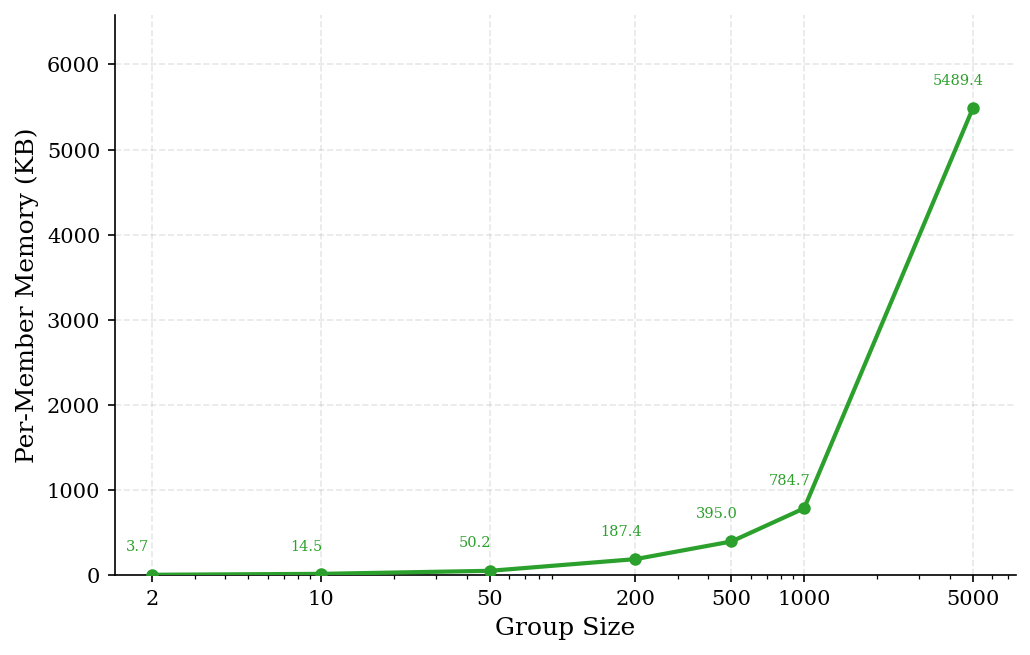

In [16]:
# --- Figure 7: Per-member memory usage of MLS group state ---

MEMORY_USAGE_PATH = Path('crates/mls-srtp-core/benches/results/memory_usage.json')

with open(MEMORY_USAGE_PATH) as f:
    mem_data = json.load(f)

# extracting group sizes and memory usage
mem_sizes = np.array([d['group_size'] for d in mem_data])
mem_bytes = np.array([d['bytes'] for d in mem_data])

# converting to KB
mem_kb = mem_bytes / 1024.0

# printing table
print(f'{"Group Size":>12s}  {"Bytes":>10s}  {"KB":>10s}')
print('-' * 36)
for i in range(len(mem_sizes)):
    print(f'{mem_sizes[i]:>12d}  {mem_bytes[i]:>10d}  {mem_kb[i]:>10.1f}')

# per-member cost
print(f'\nPer-member cost (largest group): {mem_bytes[-1] / mem_sizes[-1]:.0f} bytes')

# plotting 
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(mem_sizes, mem_kb, 'o-', color='#2ca02c', linewidth=2, markersize=5, zorder=5)

# value labels on each point
for i in range(len(mem_sizes)):
    ax.annotate(f'{mem_kb[i]:.1f}', (mem_sizes[i], mem_kb[i]),
                textcoords='offset points', xytext=(-7, 10),
                fontsize=7, ha='center', va='bottom', color='#2ca02c')

ax.set_xscale('log')
ax.set_xlabel('Group Size')
ax.set_ylabel('Per-Member Memory (KB)')

ax.set_xticks(mem_sizes)
ax.set_xticklabels([str(s) for s in mem_sizes])
ax.xaxis.set_minor_formatter(ticker.NullFormatter())

ax.set_ylim(0, max(mem_kb) * 1.2)
ax.set_xlim(mem_sizes[0] * 0.7, mem_sizes[-1] * 1.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig7_memory_usage.pdf')
plt.savefig(FIGURES_DIR / 'fig7_memory_usage.png')
plt.show()

## Figure 8: SRTCP Interleaving Overhead

Compares SRTP `protect()` throughput with and without periodic
SRTCP `protect_rtcp()` interleaving, for the two ST 2110-10 MTU sizes
(standard 1424 B and jumbo 8924 B).

For each payload size, two benchmarks are run:
1. **Baseline:** `protect()` loop (no RTCP)
2. **Interleaved:** same loop, but every 5 wall-clock seconds
   (RFC 3550 §6.2 minimum interval) a `protect_rtcp()` call is
   triggered on a 100-byte RTCP packet

The RTCP packet size is 100 bytes, based on real-world examples:
- [ShareTechnote](https://www.sharetechnote.com/html/IMS_SIP_RTP_RTCP.html): 72-byte RTCP packet
- [Wireshark](https://wiki.wireshark.org/RTCP): 100-byte RTCP packet

Data from Criterion results in `criterion/srtp_rtcp_interleaving/`.

Scenario                        Baseline   Interleaved      Diff
--------------------------------------------------------------
Standard MTU (1424 B)             46.19        46.15    -0.09%
Jumbo MTU (8924 B)                69.20        68.93    -0.39%


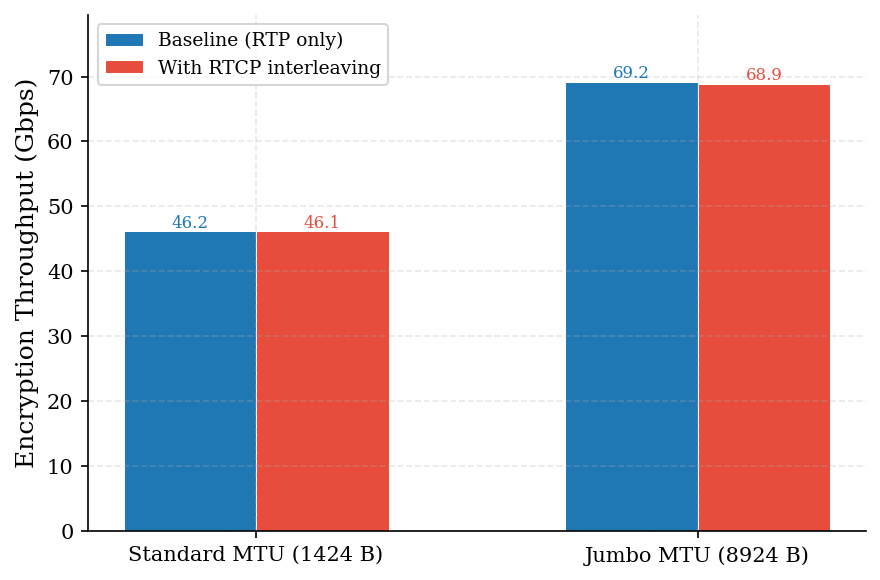

In [17]:
# --- Figure 8: SRTCP interleaving overhead ---

RTCP_DIR = CRITERION_DIR / 'srtp_rtcp_interleaving'

# Loading baseline and interleaved results for each MTU size.
# Directory structure: srtp_rtcp_interleaving/{baseline,interleaved}/<label>/new/estimates.json
scenarios = [
    (1424, '1424B_standard', 'Standard MTU (1424 B)'),
    (8924, '8924B_jumbo',    'Jumbo MTU (8924 B)'),
]

# Each SRTP packet, besides the payload, consists of:
# - RTP header: 12 bytes
# - GCM tag: 16 bytes
RTP_HDR = 12
GCM_TAG = 16

# collecting baseline throughput, interleaved throughput, and labels 
baseline_tp = []
interleaved_tp = []
labels = []

# calculating baseline and interleaved throughput for each MTU
for payload_size, label, display_name in scenarios:
    packet_bytes = RTP_HDR + payload_size + GCM_TAG

    # baseline
    est_path = RTCP_DIR / 'baseline' / label / 'new' / 'estimates.json'
    with open(est_path) as f:
        mean_ns = json.load(f)['mean']['point_estimate']
    baseline_tp.append((packet_bytes * 8) / mean_ns)  # Gbps

    # interleaved
    est_path = RTCP_DIR / 'interleaved' / label / 'new' / 'estimates.json'
    with open(est_path) as f:
        mean_ns = json.load(f)['mean']['point_estimate']
    interleaved_tp.append((packet_bytes * 8) / mean_ns)  # Gbps

    labels.append(display_name)

# printing summary
print(f'{"Scenario":<28s}  {"Baseline":>10s}  {"Interleaved":>12s}  {"Diff":>8s}')
print('-' * 62)
for i in range(len(scenarios)):
    diff_pct = (interleaved_tp[i] - baseline_tp[i]) / baseline_tp[i] * 100
    print(f'{labels[i]:<28s}  {baseline_tp[i]:>9.2f}  {interleaved_tp[i]:>11.2f}  {diff_pct:>+7.2f}%')

# --- Grouped bar chart ---

x = np.arange(len(labels))
bar_width = 0.3

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.bar(x - bar_width/2, baseline_tp, bar_width,
               color='#1f77b4', edgecolor='white', linewidth=0.5,
               label='Baseline (RTP only)')
bars2 = ax.bar(x + bar_width/2, interleaved_tp, bar_width,
               color='#e74c3c', edgecolor='white', linewidth=0.5,
               label='With RTCP interleaving')

# value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=8, color='#1f77b4')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():.1f}', ha='center', va='bottom',
            fontsize=8, color='#e74c3c')

ax.set_ylabel('Encryption Throughput (Gbps)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, max(max(baseline_tp), max(interleaved_tp)) * 1.15)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig8_rtcp_interleaving.pdf')
plt.savefig(FIGURES_DIR / 'fig8_rtcp_interleaving.png')
plt.show()